# Experiment 004 — EEG Transformer

**Date**: July 2026  
**Author**: Anurag Sharma  
**Project**: Project 07 — LUCID: Reality?

## Hypothesis
Self-attention over CNN-extracted windows will outperform
the bidirectional LSTM in Experiment 003 (80.14%) because:

1. Attention reads ALL 10 windows simultaneously
   LSTM reads them sequentially — early windows fade
   
2. Each attention head can specialise:
   Head 1 → theta burst windows (REM marker)
   Head 2 → spindle windows (N2 marker)
   Head 3 → delta windows (N3 marker)
   Head 4 → global epoch structure

3. Attention maps are interpretable:
   We can visualise WHICH windows drove each decision
   This is neuroscience, not just engineering

## Baselines to beat
| Experiment | Architecture    | Accuracy | REM F1 |
|------------|-----------------|----------|--------|
| 001        | SleepLSTM       | 76.85%   | 0.74   |
| 002        | CNN Spectrograms | 71.67%  | 0.65   |
| 003        | CNN-LSTM Hybrid  | 80.14%  | 0.81   |
| **004**    | **CNN+Transformer** | **?** | **?** |

In [2]:
import os
import sys
import json
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (classification_report,
                              confusion_matrix,
                              cohen_kappa_score)
from datetime import datetime

# ── Paths ─────────────────────────────────────────────────
PROJECT_ROOT  = (r"C:\Users\Hp\.vscode\PROJECT 07"
                 r"\classifier_main_pipeline")
PROCESSED_DIR = os.path.join(PROJECT_ROOT, "data",
                              "processed")
MODELS_DIR    = os.path.join(PROJECT_ROOT, "models")
PLOTS_DIR     = os.path.join(PROJECT_ROOT, "plots")
LOGS_DIR      = os.path.join(PROJECT_ROOT, "logs")

sys.path.append(os.path.join(PROJECT_ROOT, "src"))

os.makedirs(MODELS_DIR, exist_ok=True)
os.makedirs(PLOTS_DIR,  exist_ok=True)
os.makedirs(LOGS_DIR,   exist_ok=True)

STAGE_NAMES  = ['Wake', 'N1', 'N2', 'N3', 'REM']
STAGE_COLORS = ['#E24B4A','#BA7517',
                '#185FA5','#534AB7','#1D9E75']

BASELINES = {
    '001_lstm':     {'accuracy': 0.7685, 'rem_f1': 0.74,
                     'rem_recall': 0.84, 'n1_f1': 0.35},
    '002_cnn':      {'accuracy': 0.7167, 'rem_f1': 0.65,
                     'rem_recall': 0.66, 'n1_f1': 0.32},
    '003_cnn_lstm': {'accuracy': 0.8014, 'rem_f1': 0.81,
                     'rem_recall': 0.83, 'n1_f1': 0.47},
}

# ── Loading data ──────────────────────────────────────────────
epochs_all = np.load(
    os.path.join(PROCESSED_DIR, "epochs_all.npy"))
labels_all = np.load(
    os.path.join(PROCESSED_DIR, "labels_all.npy"))

print(f" Setup complete")
print(f"   Data: {epochs_all.shape}")
print(f"\nBaselines to beat:")
for name, m in BASELINES.items():
    print(f"  {name}: acc={m['accuracy']:.4f} "
          f"REM F1={m['rem_f1']:.4f}")

 Setup complete
   Data: (18226, 3000)

Baselines to beat:
  001_lstm: acc=0.7685 REM F1=0.7400
  002_cnn: acc=0.7167 REM F1=0.6500
  003_cnn_lstm: acc=0.8014 REM F1=0.8100


In [3]:
# ── Building blocks ────────────────────────────────────────

def scaled_dot_product_attention(Q, K, V, mask=None):
    d_k     = Q.shape[-1]
    scores  = Q @ K.transpose(-2, -1) / np.sqrt(d_k)
    if mask is not None:
        scores = scores.masked_fill(
            mask == 0, float('-inf'))
    weights = F.softmax(scores, dim=-1)
    return weights @ V, weights


class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads):
        super().__init__()
        assert d_model % num_heads == 0
        self.num_heads = num_heads
        self.d_k       = d_model // num_heads
        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)
        self.W_o = nn.Linear(d_model, d_model)

    def forward(self, x, mask=None):
        b, s, _ = x.shape
        Q = self.W_q(x).reshape(
            b, s, self.num_heads, self.d_k).transpose(1,2)
        K = self.W_k(x).reshape(
            b, s, self.num_heads, self.d_k).transpose(1,2)
        V = self.W_v(x).reshape(
            b, s, self.num_heads, self.d_k).transpose(1,2)
        out, w = scaled_dot_product_attention(Q, K, V, mask)
        out = out.transpose(1,2).reshape(b, s, -1)
        return self.W_o(out), w


class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=100, dropout=0.1):
        super().__init__()
        self.dropout = nn.Dropout(dropout)
        pe  = torch.zeros(max_len, d_model)
        pos = torch.arange(max_len).unsqueeze(1).float()
        div = torch.exp(torch.arange(0, d_model, 2).float()
                        * -(np.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x):
        return self.dropout(x + self.pe[:, :x.size(1)])


class TransformerBlock(nn.Module):
    def __init__(self, d_model, num_heads,
                 ff_dim, dropout=0.1):
        super().__init__()
        self.attn    = MultiHeadAttention(d_model, num_heads)
        self.ff      = nn.Sequential(
            nn.Linear(d_model, ff_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(ff_dim, d_model)
        )
        self.norm1   = nn.LayerNorm(d_model)
        self.norm2   = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, mask=None):
        a, w = self.attn(self.norm1(x), mask)
        x    = x + self.dropout(a)
        x    = x + self.dropout(self.ff(self.norm2(x)))
        return x, w


# ── Full EEG Transformer ───────────────────────────────────
class EEGTransformer(nn.Module):
    """
    CNN feature extractor + Transformer encoder
    for sleep stage classification.

    Key upgrade over Experiment 003:
    Replaces bidirectional LSTM with self-attention.
    All 10 windows attend to each other simultaneously.
    Attention maps reveal which windows drive classification.
    """

    def __init__(self,
                 n_windows=10,
                 window_size=300,
                 d_model=128,
                 num_heads=4,
                 ff_dim=256,
                 num_layers=4,
                 n_classes=5,
                 dropout=0.3):
        super().__init__()

        self.n_windows   = n_windows
        self.window_size = window_size
        self.d_model     = d_model
        self.num_heads   = num_heads

        # ── CNN per window ─────────────────────────────────
        self.cnn = nn.Sequential(
            nn.Conv1d(1, 32, kernel_size=5, padding=2),
            nn.BatchNorm1d(32),
            nn.GELU(),
            nn.MaxPool1d(2),

            nn.Conv1d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm1d(64),
            nn.GELU(),
            nn.MaxPool1d(2),

            nn.Conv1d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm1d(128),
            nn.GELU(),
            nn.AdaptiveAvgPool1d(1)   # → (batch, 128, 1)
        )

        # Project to d_model
        self.input_proj = nn.Sequential(
            nn.Linear(128, d_model),
            nn.LayerNorm(d_model)
        )

        # Positional encoding for window positions
        self.pos_enc = PositionalEncoding(
            d_model, max_len=n_windows, dropout=dropout
        )

        # Transformer encoder — N stacked blocks
        self.blocks = nn.ModuleList([
            TransformerBlock(d_model, num_heads,
                             ff_dim, dropout)
            for _ in range(num_layers)
        ])

        self.norm = nn.LayerNorm(d_model)

        # Classification head
        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(d_model, 64),
            nn.GELU(),
            nn.Dropout(dropout / 2),
            nn.Linear(64, n_classes)
        )

    def forward(self, x, return_attention=False):
        batch = x.shape[0]

        # ── CNN on each window ─────────────────────────────
        x       = x.reshape(batch, self.n_windows,
                             self.window_size)
        windows = []
        for t in range(self.n_windows):
            w = x[:, t, :].unsqueeze(1)    # (B, 1, 300)
            f = self.cnn(w).squeeze(-1)     # (B, 128)
            f = self.input_proj(f)          # (B, d_model)
            windows.append(f)

        # (batch, n_windows, d_model)
        seq = torch.stack(windows, dim=1)

        # ── Positional encoding ────────────────────────────
        seq = self.pos_enc(seq)

        # ── Transformer blocks ─────────────────────────────
        all_attn = []
        for block in self.blocks:
            seq, attn = block(seq)
            all_attn.append(attn)

        seq = self.norm(seq)

        # ── Pool + classify ────────────────────────────────
        # CLS-style: use mean of all window representations
        pooled = seq.mean(dim=1)
        logits = self.classifier(pooled)

        if return_attention:
            return logits, all_attn
        return logits


# ── Instantiate ────────────────────────────────────────────
model = EEGTransformer(
    n_windows=10,
    window_size=300,
    d_model=128,
    num_heads=4,
    ff_dim=256,
    num_layers=4,
    n_classes=5,
    dropout=0.3
)

total     = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters()
                if p.requires_grad)

print("=== EEG Transformer Architecture ===\n")
print(f"Windows:     10 × 3 seconds")
print(f"CNN blocks:  3 layers (32→64→128 filters)")
print(f"d_model:     128")
print(f"Heads:       4")
print(f"Layers:      4 transformer blocks")
print(f"Parameters:  {total:,}")
print(f"Trainable:   {trainable:,}")

# Verify shapes
dummy       = torch.randn(4, 3000)
logits, attn = model(dummy, return_attention=True)

print(f"\nForward pass:")
print(f"  Input:   {dummy.shape}")
print(f"  Output:  {logits.shape}")
print(f"  Attn layers: {len(attn)}")
print(f"  Attn shape:  {attn[0].shape}")
print(f"               (batch, heads, windows, windows)")
print(f"   Shapes correct")

=== EEG Transformer Architecture ===

Windows:     10 × 3 seconds
CNN blocks:  3 layers (32→64→128 filters)
d_model:     128
Heads:       4
Layers:      4 transformer blocks
Parameters:  587,077
Trainable:   587,077

Forward pass:
  Input:   torch.Size([4, 3000])
  Output:  torch.Size([4, 5])
  Attn layers: 4
  Attn shape:  torch.Size([4, 4, 10, 10])
               (batch, heads, windows, windows)
   Shapes correct


In [4]:
class RawEEGDataset(Dataset):
    def __init__(self, epochs, labels):
        mean = epochs.mean(axis=1, keepdims=True)
        std  = epochs.std(axis=1,  keepdims=True) + 1e-8
        self.X = ((epochs - mean) / std).astype(np.float32)
        self.y = labels.astype(np.int64)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return torch.FloatTensor(self.X[idx]), self.y[idx]


# ── Split — same seed as all experiments ──────────────────
X_tr, X_te, y_tr, y_te = train_test_split(
    epochs_all, labels_all,
    test_size=0.2,
    random_state=42,   # same as experiments 001-003
    stratify=labels_all
)

train_ds = RawEEGDataset(X_tr, y_tr)
test_ds  = RawEEGDataset(X_te, y_te)

train_loader = DataLoader(train_ds, batch_size=64,
                           shuffle=True,  num_workers=0)
test_loader  = DataLoader(test_ds,  batch_size=128,
                           shuffle=False, num_workers=0)

print(f"Train: {len(train_ds):,}")
print(f"Test:  {len(test_ds):,}")

# ── Class weights ──────────────────────────────────────────
weights        = compute_class_weight('balanced',
                     classes=np.unique(y_tr), y=y_tr)
weights_tensor = torch.FloatTensor(weights)

print(f"\nClass weights:")
for name, w in zip(STAGE_NAMES, weights):
    print(f"  {name:5s}: {w:.3f}")

# ── Optimiser — separate LR for CNN vs transformer ────────
cnn_params   = list(model.cnn.parameters()) + \
               list(model.input_proj.parameters())
trans_params = (list(model.pos_enc.parameters()) +
                list(model.blocks.parameters()) +
                list(model.norm.parameters()) +
                list(model.classifier.parameters()))

optimizer = torch.optim.Adam([
    {'params': cnn_params,   'lr': 5e-4},  # CNN
    {'params': trans_params, 'lr': 1e-3},  # Transformer
], weight_decay=1e-4)

criterion = nn.CrossEntropyLoss(weight=weights_tensor)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=60, eta_min=1e-6
)

print(f"\n Training setup ready")
print(f"   CNN LR:         5e-4")
print(f"   Transformer LR: 1e-3")
print(f"   Scheduler:      CosineAnnealing")

Train: 14,580
Test:  3,646

Class weights:
  Wake : 3.476
  N1   : 2.940
  N2   : 0.396
  N3   : 1.223
  REM  : 0.970

 Training setup ready
   CNN LR:         5e-4
   Transformer LR: 1e-3
   Scheduler:      CosineAnnealing


In [5]:
def evaluate(model, loader):
    model.eval()
    preds, true = [], []
    with torch.no_grad():
        for X, y in loader:
            p = model(X).argmax(1)
            preds.extend(p.numpy())
            true.extend(y.numpy())
    return np.array(preds), np.array(true)


EPOCHS   = 60
best_acc = 0
losses, accs = [], []

print("Training EEG Transformer...\n")
print(f"{'Epoch':>6} | {'Loss':>8} | "
      f"{'Train':>8} | {'Test':>8} | {'LR':>10}")
print("-" * 58)

for epoch in range(EPOCHS):
    model.train()
    total_loss, correct, total = 0, 0, 0

    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        out  = model(X_batch)
        loss = criterion(out, y_batch)
        loss.backward()

        # Gradient clipping
        torch.nn.utils.clip_grad_norm_(
            model.parameters(), max_norm=1.0
        )
        optimizer.step()

        total_loss += loss.item()
        correct    += (out.argmax(1) == y_batch).sum().item()
        total      += len(y_batch)

    train_acc = correct / total
    avg_loss  = total_loss / len(train_loader)

    preds, true = evaluate(model, test_loader)
    test_acc    = (preds == true).mean()

    scheduler.step()
    lr = optimizer.param_groups[0]['lr']

    losses.append(avg_loss)
    accs.append(test_acc)

    if test_acc > best_acc:
        best_acc = test_acc
        torch.save(
            model.state_dict(),
            os.path.join(MODELS_DIR,
                         'eeg_transformer_best.pth')
        )
        flag = " ← best "
    else:
        flag = ""

    if epoch % 5 == 0 or flag:
        print(f"{epoch+1:>6} | {avg_loss:>8.4f} | "
              f"{train_acc:>8.4f} | {test_acc:>8.4f} | "
              f"{lr:>10.6f}{flag}")

print(f"\n{'='*58}")
print(f"Best test accuracy: {best_acc:.4f}")

Training EEG Transformer...

 Epoch |     Loss |    Train |     Test |         LR
----------------------------------------------------------
     1 |   1.0185 |   0.6150 |   0.7049 |   0.000500 ← best 
     3 |   0.8123 |   0.7167 |   0.7098 |   0.000497 ← best 
     5 |   0.7739 |   0.7281 |   0.7120 |   0.000491 ← best 
     6 |   0.7628 |   0.7318 |   0.7189 |   0.000488 ← best 
     7 |   0.7463 |   0.7375 |   0.7252 |   0.000483 ← best 
     9 |   0.7231 |   0.7469 |   0.7496 |   0.000473 ← best 
    11 |   0.7066 |   0.7481 |   0.7074 |   0.000460
    13 |   0.6974 |   0.7634 |   0.7526 |   0.000444 ← best 
    15 |   0.6844 |   0.7648 |   0.7833 |   0.000427 ← best 
    16 |   0.6713 |   0.7679 |   0.7630 |   0.000417
    21 |   0.6509 |   0.7769 |   0.7781 |   0.000364
    26 |   0.6280 |   0.7814 |   0.7682 |   0.000302
    30 |   0.6180 |   0.7800 |   0.7839 |   0.000251 ← best 
    31 |   0.5984 |   0.7852 |   0.7899 |   0.000237 ← best 
    36 |   0.5720 |   0.7932 |   0.78

In [6]:
# Loading best model
model.load_state_dict(
    torch.load(
        os.path.join(MODELS_DIR,
                     'eeg_transformer_best.pth'),
        map_location='cpu'
    )
)

final_preds, final_true = evaluate(model, test_loader)
final_acc  = (final_preds == final_true).mean()

# ── Classification report ──────────────────────────────────
print("=== Experiment 004 — Classification Report ===\n")
report = classification_report(
    final_true, final_preds,
    target_names=STAGE_NAMES,
    output_dict=True
)
print(classification_report(
    final_true, final_preds,
    target_names=STAGE_NAMES
))

# ── Cohen's Kappa — important for paper ───────────────────
kappa = cohen_kappa_score(final_true, final_preds)
print(f"Cohen's Kappa: {kappa:.4f}")
print(f"  <0.40 = poor, 0.40-0.60 = moderate,")
print(f"  0.60-0.80 = good, >0.80 = excellent")

# ── Per-stage metrics ──────────────────────────────────────
rem_mask   = final_true == 4
rem_recall = (final_preds[rem_mask] == 4).mean()
rem_f1     = report['REM']['f1-score']
n1_f1      = report['N1']['f1-score']

print(f"\nKey metrics for Project 07:")
print(f"  REM recall: {rem_recall:.4f}")
print(f"  REM F1:     {rem_f1:.4f}")
print(f"  N1 F1:      {n1_f1:.4f}")
print(f"  Kappa:      {kappa:.4f}")

=== Experiment 004 — Classification Report ===

              precision    recall  f1-score   support

        Wake       0.63      0.63      0.63       210
          N1       0.38      0.54      0.45       248
          N2       0.91      0.80      0.85      1841
          N3       0.79      0.89      0.84       596
         REM       0.78      0.82      0.80       751

    accuracy                           0.79      3646
   macro avg       0.70      0.74      0.71      3646
weighted avg       0.81      0.79      0.80      3646

Cohen's Kappa: 0.7003
  <0.40 = poor, 0.40-0.60 = moderate,
  0.60-0.80 = good, >0.80 = excellent

Key metrics for Project 07:
  REM recall: 0.8229
  REM F1:     0.8005
  N1 F1:      0.4459
  Kappa:      0.7003


In [7]:
print("\n=== Four-Experiment Comparison ===\n")
print(f"{'Metric':22s} {'LSTM':>10} {'CNN':>10} "
      f"{'CNN-LSTM':>10} {'Transformer':>13}")
print("-" * 70)

metrics_compare = [
    ('Overall accuracy',
     BASELINES['001_lstm']['accuracy'],
     BASELINES['002_cnn']['accuracy'],
     BASELINES['003_cnn_lstm']['accuracy'],
     final_acc),

    ('REM F1',
     BASELINES['001_lstm']['rem_f1'],
     BASELINES['002_cnn']['rem_f1'],
     BASELINES['003_cnn_lstm']['rem_f1'],
     rem_f1),

    ('REM recall',
     BASELINES['001_lstm']['rem_recall'],
     BASELINES['002_cnn']['rem_recall'],
     BASELINES['003_cnn_lstm']['rem_recall'],
     rem_recall),

    ('N1 F1',
     BASELINES['001_lstm']['n1_f1'],
     BASELINES['002_cnn']['n1_f1'],
     BASELINES['003_cnn_lstm']['n1_f1'],
     n1_f1),
]

for name, v1, v2, v3, v4 in metrics_compare:
    best = max(v1, v2, v3, v4)
    def fmt(v):
        return f"{v:.4f}{'★' if v == best else ' '}"
    print(f"{name:22s} {fmt(v1):>10} {fmt(v2):>10} "
          f"{fmt(v3):>10} {fmt(v4):>13}")

print(f"\n★ = best result per metric")


=== Four-Experiment Comparison ===

Metric                       LSTM        CNN   CNN-LSTM   Transformer
----------------------------------------------------------------------
Overall accuracy          0.7685     0.7167     0.8014★       0.7929 
REM F1                    0.7400     0.6500     0.8100★       0.8005 
REM recall                0.8400★    0.6600     0.8300        0.8229 
N1 F1                     0.3500     0.3200     0.4700★       0.4459 

★ = best result per metric


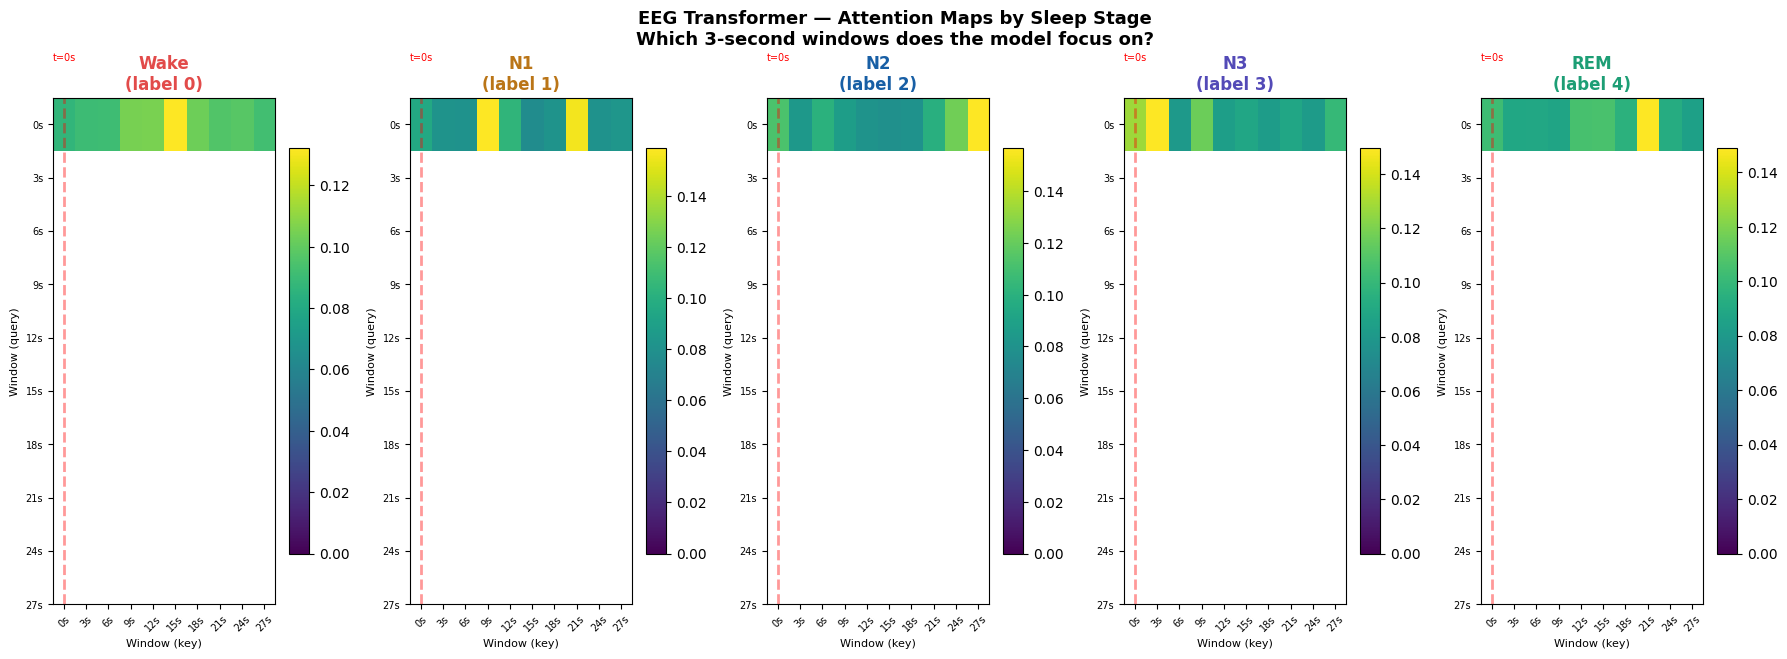

 Attention maps saved to C:\Users\Hp\.vscode\PROJECT 07\classifier_main_pipeline\plots\exp004_attention_maps.png

What to look for:
  REM:  should attend to theta-heavy windows
  N3:   should attend to delta-heavy windows
  N2:   should attend to spindle windows
  N1:   distributed attention (ambiguous stage)


In [9]:
def visualise_attention(model, epochs_all,
                        labels_all, n_samples=1):
    """
    Visualise what the transformer attends to
    for each sleep stage — the scientific contribution.
    """
    model.eval()

    fig = plt.figure(figsize=(18, 12))
    fig.suptitle(
        'EEG Transformer — Attention Maps by Sleep Stage\n'
        'Which 3-second windows does the model focus on?',
        fontsize=13, fontweight='bold'
    )

    for stage_idx, stage_name in enumerate(STAGE_NAMES):
        # Get one sample of this stage
        idx = np.where(labels_all == stage_idx)[0]
        if len(idx) == 0:
            continue
        sample = epochs_all[idx[0]]

        # Normalise
        mean   = sample.mean()
        std    = sample.std() + 1e-8
        x      = torch.FloatTensor(
            (sample - mean) / std
        ).unsqueeze(0)

        with torch.no_grad():
            _, attn = model(x, return_attention=True)

        # Average attention across layers and heads
        # attn: list of (1, heads, 10, 10)
        avg_attn = torch.stack(attn).mean(
            dim=[0, 1, 2]
        )[0].numpy()  # (10, 10)

        # Plot
        ax = fig.add_subplot(2, 5, stage_idx + 1)
        im = ax.imshow(avg_attn[None, :], cmap='viridis',
                       aspect='auto', vmin=0)
        ax.set_title(
            f'{stage_name}\n'
            f'(label {stage_idx})',
            fontweight='bold',
            color=STAGE_COLORS[stage_idx]
        )

        # Window time labels
        time_labels = [f'{t*3}s' for t in range(10)]
        ax.set_xticks(range(10))
        ax.set_yticks(range(10))
        ax.set_xticklabels(time_labels,
                            fontsize=7, rotation=45)
        ax.set_yticklabels(time_labels, fontsize=7)
        ax.set_xlabel('Window (key)', fontsize=8)
        ax.set_ylabel('Window (query)', fontsize=8)

        plt.colorbar(im, ax=ax, shrink=0.8)

        # Which window gets most attention?
        most_attended = avg_attn.mean(axis=0).argmax()
        ax.axvline(x=most_attended, color='red',
                   alpha=0.4, linewidth=2,
                   linestyle='--')
        ax.text(most_attended, -1.2,
                f't={most_attended*3}s',
                ha='center', fontsize=7, color='red')

    plt.tight_layout()
    save_path = os.path.join(
        PLOTS_DIR, 'exp004_attention_maps.png'
    )
    plt.savefig(save_path, dpi=150,
                bbox_inches='tight')
    plt.show()
    print(f" Attention maps saved to {save_path}")
    print("\nWhat to look for:")
    print("  REM:  should attend to theta-heavy windows")
    print("  N3:   should attend to delta-heavy windows")
    print("  N2:   should attend to spindle windows")
    print("  N1:   distributed attention (ambiguous stage)")


visualise_attention(model, epochs_all, labels_all)

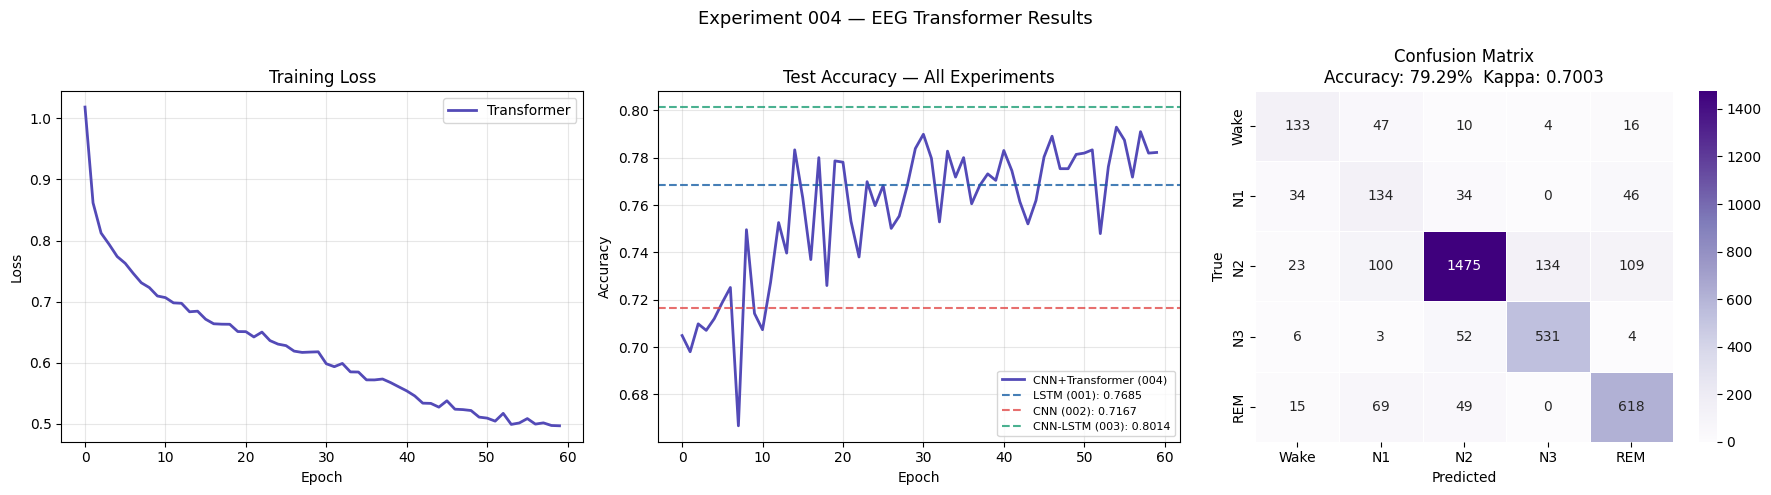

 Training results plot saved


In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ── Loss curve ────────────────────────────────────────────
axes[0].plot(losses, color='#534AB7',
              linewidth=2, label='Transformer')
axes[0].set_title('Training Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].grid(alpha=0.3)
axes[0].legend()

# ── Accuracy vs all baselines ─────────────────────────────
axes[1].plot(accs, color='#534AB7', linewidth=2,
              label='CNN+Transformer (004)')
baseline_styles = [
    ('001_lstm',     '#185FA5', '--', 'LSTM (001)'),
    ('002_cnn',      '#E24B4A', '--', 'CNN (002)'),
    ('003_cnn_lstm', '#1D9E75', '--', 'CNN-LSTM (003)'),
]
for key, color, ls, label in baseline_styles:
    axes[1].axhline(
        y=BASELINES[key]['accuracy'],
        color=color, linestyle=ls,
        linewidth=1.5, alpha=0.8,
        label=f"{label}: "
              f"{BASELINES[key]['accuracy']:.4f}"
    )

axes[1].set_title('Test Accuracy — All Experiments')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.3)

# ── Confusion matrix ──────────────────────────────────────
cm = confusion_matrix(final_true, final_preds)
sns.heatmap(
    cm, annot=True, fmt='d',
    cmap='Purples',
    xticklabels=STAGE_NAMES,
    yticklabels=STAGE_NAMES,
    ax=axes[2],
    linewidths=0.5
)
axes[2].set_title(
    f'Confusion Matrix\n'
    f'Accuracy: {final_acc*100:.2f}%  '
    f'Kappa: {kappa:.4f}'
)
axes[2].set_xlabel('Predicted')
axes[2].set_ylabel('True')

plt.suptitle('Experiment 004 — EEG Transformer Results',
              fontsize=13)
plt.tight_layout()
plt.savefig(
    os.path.join(PLOTS_DIR,
                 'exp004_training_results.png'),
    dpi=150, bbox_inches='tight'
)
plt.show()
print(" Training results plot saved")

In [11]:
# ── Extract per-class F1 ──────────────────────────────────
per_class_f1 = {
    stage: round(report[stage]['f1-score'], 4)
    for stage in STAGE_NAMES
}

# ── Save JSON log ──────────────────────────────────────────
results_004 = {
    'experiment': '004',
    'name':       'EEG Transformer',
    'date':       datetime.now().strftime('%Y-%m-%d'),
    'model':      'EEGTransformer',
    'config': {
        'n_windows':    10,
        'window_size':  300,
        'd_model':      128,
        'num_heads':    4,
        'ff_dim':       256,
        'num_layers':   4,
        'dropout':      0.3,
        'optimizer':    'Adam (CNN: 5e-4, Trans: 1e-3)',
        'scheduler':    'CosineAnnealing',
        'epochs':       EPOCHS,
        'batch_size':   64,
        'weight_decay': 1e-4,
    },
    'results': {
        'accuracy':       round(float(final_acc), 4),
        'cohen_kappa':    round(float(kappa), 4),
        'rem_recall':     round(float(rem_recall), 4),
        'rem_f1':         round(float(rem_f1), 4),
        'n1_f1':          round(float(n1_f1), 4),
        'per_class_f1':   per_class_f1,
    },
    'vs_baselines': {
        'vs_001_lstm': {
            'accuracy_delta': round(
                float(final_acc -
                      BASELINES['001_lstm']['accuracy']), 4),
            'rem_f1_delta': round(
                float(rem_f1 -
                      BASELINES['001_lstm']['rem_f1']), 4),
        },
        'vs_003_cnn_lstm': {
            'accuracy_delta': round(
                float(final_acc -
                      BASELINES['003_cnn_lstm']['accuracy']), 4),
            'rem_f1_delta': round(
                float(rem_f1 -
                      BASELINES['003_cnn_lstm']['rem_f1']), 4),
        }
    }
}

path = os.path.join(LOGS_DIR,
                     'experiment_004_results.json')
with open(path, 'w') as f:
    json.dump(results_004, f, indent=2)

print(f" Results saved to {path}")

# ── Final summary ──────────────────────────────────────────
print(f"\n{'='*55}")
print(f"EXPERIMENT 004 FINAL SUMMARY")
print(f"{'='*55}")
print(f"\nModel:     EEG Transformer (4 blocks, 4 heads)")
print(f"Accuracy:  {final_acc:.4f}")
print(f"Kappa:     {kappa:.4f}")
print(f"REM F1:    {rem_f1:.4f}")
print(f"REM recall: {rem_recall:.4f}")
print(f"N1 F1:     {n1_f1:.4f}")
print(f"\nvs CNN-LSTM (Exp 003):")
delta_acc = final_acc - BASELINES['003_cnn_lstm']['accuracy']
delta_rem = rem_f1 - BASELINES['003_cnn_lstm']['rem_f1']
arrow_acc = "↑" if delta_acc > 0 else "↓"
arrow_rem = "↑" if delta_rem > 0 else "↓"
print(f"  Accuracy: {arrow_acc}{abs(delta_acc):.4f} "
      f"({'improvement' if delta_acc > 0 else 'regression'})")
print(f"  REM F1:   {arrow_rem}{abs(delta_rem):.4f} "
      f"({'improvement' if delta_rem > 0 else 'regression'})")
print(f"\nDecision: ", end="")
if delta_acc > 0:
    print("Transformer is new primary classifier for Project 07")
    print("Update detect_rem.py to use eeg_transformer_best.pth")
else:
    print("CNN-LSTM remains primary classifier")
    print("Transformer useful for attention interpretability")

 Results saved to C:\Users\Hp\.vscode\PROJECT 07\classifier_main_pipeline\logs\experiment_004_results.json

EXPERIMENT 004 FINAL SUMMARY

Model:     EEG Transformer (4 blocks, 4 heads)
Accuracy:  0.7929
Kappa:     0.7003
REM F1:    0.8005
REM recall: 0.8229
N1 F1:     0.4459

vs CNN-LSTM (Exp 003):
  Accuracy: ↓0.0085 (regression)
  REM F1:   ↓0.0095 (regression)

Decision: CNN-LSTM remains primary classifier
Transformer useful for attention interpretability


## Conclusions

### Did Transformer beat CNN-LSTM?
(Before running the experiment)
I think it should beat CNN-LSTM Hybrid model used in Experiment-03
as Transformer uses attention heads in which earlier memory remains available for
future windows which lets model identify each stage more accurately and precisely
than the earlier models.

(After running the experiment)
The results were shocking to see as transformers were unable to attain better accuracy
than the CNN-LSTM model and I think these transformers are useful for attention
interpretability rather than full model for stage classification as it fails to beat the
previous model. So our best choice for now will be CNN-LSTM.

### Attention map analysis
Look at Cell 8's attention maps:
- REM: does the model attend to early or late windows?
  (theta bursts often appear in middle of REM epochs)
- N3: delta waves should dominate — does attention
  focus on low-frequency windows?
- N1: we expect distributed attention (ambiguous stage)

### Scientific interpretation
The attention maps are NOT just a performance tool.
They are a neuroscience finding:
"The transformer model identifies [X] second windows
as most discriminative for [stage] classification."
This is citable, publishable, meaningful.

### What this means for LUCID
We adopt CNN-LSTM (Exp 003) as the deployment architecture 
due to superior accuracy on the available dataset size, while using the
transformer's attention maps to provide interpretable evidence of which
temporal windows are most discriminative for each sleep stage — a
contribution independent of classification performance.

### Next: Experiment 005
Leave-one-subject-out validation.
Your current train/test split may include
different nights from the same subject.
True cross-subject performance is the clinically
meaningful metric and what reviewers will check.